# 🤖 SmartSpend — AI Engineer: Deep Learning Model
**Coding Camp 2026 | CC26-PSU146**

Notebook ini dibuat oleh AI Engineer untuk memenuhi checklist MVP:
- ✅ Deep Learning dengan **TensorFlow Functional API**
- ✅ Komponen kustom: **Custom Layer + Custom Callback**
- ✅ Menyimpan model dalam format **`.keras` (SavedModel)**
- ✅ Kode **inference** siap produksi

---
**Task:** Multi-output model:
- **Output 1 (Klasifikasi):** Prediksi `label_rekomendasi` (Keuangan Sehat / Cukup Baik / Perlu Perbaikan)
- **Output 2 (Regresi):** Prediksi `tabungan_bulanan` yang ideal

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import joblib
import json
import os

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
Keras version: 3.13.2


## 2. Load & Preprocessing Data
> Data sudah di-EDA oleh tim Data Scientist. AI Engineer melakukan preprocessing untuk kebutuhan Deep Learning.

In [3]:
# Load dataset
df = pd.read_csv('dataset_cleaned_for_AI.csv')
print(f'Dataset shape: {df.shape}')
print(f"\nLabel distribution:")
print(df['label_rekomendasi'].value_counts())
df.head()

Dataset shape: (2138, 28)

Label distribution:
label_rekomendasi
Keuangan Sehat     1197
Cukup Baik          772
Perlu Perbaikan     169
Name: count, dtype: int64


,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
0,1160,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,...,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Keuangan Sehat
1,1824,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,...,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,Cukup Baik
2,979,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,1.0,6500000.0,...,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9,Keuangan Sehat
3,760,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,...,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Keuangan Sehat
4,875,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,Menikah,3.0,3300000.0,...,93000.0,197000.0,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3,Cukup Baik


In [4]:
# ============================================================
# PREPROCESSING
# ============================================================

# 1. Drop kolom ID (tidak relevan untuk modeling)
df = df.drop(columns=['id'])

# 2. Simpan provinsi sebagai fitur tambahan (label encode)
# Karena banyak kategori, kita gunakan frekuensi encoding
provinsi_freq = df['provinsi'].value_counts(normalize=True).to_dict()
df['provinsi_freq'] = df['provinsi'].map(provinsi_freq)
df = df.drop(columns=['provinsi'])

# 3. Label Encoding untuk kolom kategorikal
le_dict = {}
cat_cols = ['klasifikasi_wilayah', 'jenis_kelamin', 'pendidikan_terakhir',
            'status_pekerjaan', 'status_pernikahan']

for col in cat_cols:
    le = LabelEncoder()
    # Isi missing value dengan modus sebelum encode
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# 4. Isi missing value numerik dengan median
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclude target kolom dari imputasi sekarang
target_cols = ['label_rekomendasi', 'tabungan_bulanan']
num_features = [c for c in num_cols if c not in target_cols and c != 'tabungan_bulanan']

for col in df.select_dtypes(include='number').columns:
    if col != 'label_rekomendasi':  # label_rekomendasi masih string
        df[col] = df[col].fillna(df[col].median())

# 5. Encode target label klasifikasi
le_label = LabelEncoder()
df['label_encoded'] = le_label.fit_transform(df['label_rekomendasi'])
print('Label classes:', le_label.classes_)
print('Label mapping:', dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))

df.shape

Label classes: ['Cukup Baik' 'Keuangan Sehat' 'Perlu Perbaikan']
Label mapping: {'Cukup Baik': np.int64(0), 'Keuangan Sehat': np.int64(1), 'Perlu Perbaikan': np.int64(2)}


(2138, 28)

In [5]:
# ============================================================
# DEFINISI FITUR (INPUT) DAN TARGET (OUTPUT)
# ============================================================

# Fitur input untuk model
FEATURE_COLS = [
    # Demografi
    'usia', 'jenis_kelamin', 'klasifikasi_wilayah', 'pendidikan_terakhir',
    'status_pekerjaan', 'status_pernikahan', 'jumlah_tanggungan', 'provinsi_freq',
    # Keuangan utama
    'pendapatan_bulanan', 'total_pengeluaran', 'rasio_tabungan_persen',
    'skor_literasi_keuangan', 'cicilan_hutang',
    # Pengeluaran per kategori
    'pengeluaran_makanan_pokok', 'pengeluaran_lauk_pauk', 'pengeluaran_sayur_buah',
    'pengeluaran_jajan_makan_luar', 'pengeluaran_rokok_tembakau',
    'pengeluaran_perumahan_listrik', 'pengeluaran_pakaian', 'pengeluaran_kesehatan',
    'pengeluaran_pendidikan', 'pengeluaran_transportasi', 'pengeluaran_komunikasi',
    'pengeluaran_hiburan_rekreasi'
]

# Target 1: Klasifikasi kondisi keuangan
TARGET_CLASS  = 'label_encoded'
# Target 2: Regresi nominal tabungan ideal
TARGET_REGRES = 'tabungan_bulanan'

X = df[FEATURE_COLS].values.astype(np.float32)
y_class  = df[TARGET_CLASS].values.astype(np.int32)
y_regres = df[TARGET_REGRES].values.astype(np.float32)

print(f'X shape       : {X.shape}')
print(f'y_class shape : {y_class.shape}  | unique: {np.unique(y_class)}')
print(f'y_regres shape: {y_regres.shape} | range: {y_regres.min():.0f} - {y_regres.max():.0f}')

X shape       : (2138, 25)
y_class shape : (2138,)  | unique: [0 1 2]
y_regres shape: (2138,) | range: 45000 - 7453000


In [6]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT  (70 / 15 / 15)
# ============================================================

X_train, X_temp, y_c_train, y_c_temp, y_r_train, y_r_temp = train_test_split(
    X, y_class, y_regres, test_size=0.30, random_state=42, stratify=y_class
)
X_val, X_test, y_c_val, y_c_test, y_r_val, y_r_test = train_test_split(
    X_temp, y_c_temp, y_r_temp, test_size=0.50, random_state=42, stratify=y_c_temp
)

# Normalisasi fitur (fit hanya pada training data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# Normalisasi target regresi (log-scale agar training lebih stabil)
y_r_train_log = np.log1p(y_r_train)
y_r_val_log   = np.log1p(y_r_val)
y_r_test_log  = np.log1p(y_r_test)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

# Simpan scaler untuk inference
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
joblib.dump(le_label, 'label_encoder_target.pkl')
joblib.dump(provinsi_freq, 'provinsi_freq.pkl')
print('\nScaler & encoders saved.')

Train : 1496 samples
Val   : 321 samples
Test  : 321 samples

Scaler & encoders saved.


## 3. Custom Components
### 3a. Custom Layer — `AttentionLayer`
Layer ini menambahkan **mekanisme attention** sederhana agar model bisa memfokuskan perhatian pada fitur keuangan yang paling penting untuk setiap user.

In [7]:
class FinancialAttentionLayer(layers.Layer):
    """
    Custom Layer: Financial Attention
    ----------------------------------
    Memberikan bobot (attention weight) berbeda pada setiap fitur
    keuangan, sehingga model bisa fokus pada fitur yang paling
    relevan untuk setiap pengguna secara dinamis.

    Cara kerja:
    1. Hitung skor relevansi tiap fitur via dense layer kecil
    2. Normalisasi dengan softmax → attention weights
    3. Kalikan input dengan attention weights (element-wise)
    """

    def __init__(self, units=64, **kwargs):
        super(FinancialAttentionLayer, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # Bobot untuk menghitung attention score
        self.W_attention = self.add_weight(
            name='W_attention',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b_attention = self.add_weight(
            name='b_attention',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        # Proyeksi kembali ke dimensi input
        self.W_out = self.add_weight(
            name='W_out',
            shape=(self.units, input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        # Hitung attention score
        score = tf.nn.tanh(tf.matmul(inputs, self.W_attention) + self.b_attention)
        score = tf.matmul(score, self.W_out)
        # Normalisasi dengan softmax
        attention_weights = tf.nn.softmax(score, axis=-1)
        # Terapkan attention ke input
        attended = inputs * attention_weights
        return attended

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


print('✅ Custom Layer: FinancialAttentionLayer berhasil didefinisikan')

✅ Custom Layer: FinancialAttentionLayer berhasil didefinisikan


### 3b. Custom Callback — `SmartSpendCallback`
Callback ini memantau training secara real-time dan otomatis menyimpan model terbaik.

In [8]:
class SmartSpendCallback(Callback):
    """
    Custom Callback: SmartSpend Training Monitor
    ---------------------------------------------
    Memantau proses training dan:
    1. Mencetak ringkasan performa tiap epoch
    2. Menyimpan model terbaik otomatis berdasarkan val_loss
    3. Menghentikan training jika val_loss tidak membaik (early stopping)
    4. Menyimpan history training ke file JSON
    """

    def __init__(self, patience=10, save_path='best_model.keras'):
        super().__init__()
        self.patience   = patience
        self.save_path  = save_path
        self.best_loss  = np.inf
        self.wait       = 0
        self.history_log = []

    def on_train_begin(self, logs=None):
        print('=' * 60)
        print('🚀 SmartSpend Model Training Dimulai')
        print('=' * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss       = logs.get('val_loss', np.inf)
        val_class_acc  = logs.get('val_classification_output_accuracy', 0)
        val_regres_mae = logs.get('val_regression_output_mae', 0)

        # Simpan ke history log
        self.history_log.append({
            'epoch'        : epoch + 1,
            'val_loss'     : round(float(val_loss), 4),
            'val_class_acc': round(float(val_class_acc), 4),
            'val_mae'      : round(float(val_regres_mae), 4)
        })

        # Print setiap 5 epoch
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | val_loss: {val_loss:.4f} | '
                  f'val_acc: {val_class_acc:.4f} | val_mae: {val_regres_mae:.0f}')

        # Simpan model terbaik
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait      = 0
            self.model.save(self.save_path)
            if (epoch + 1) % 5 == 0:
                print(f'  💾 Model terbaik disimpan (val_loss: {val_loss:.4f})')
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                print(f'\n⛔ Early stopping pada epoch {epoch+1} '
                      f'(tidak ada perbaikan selama {self.patience} epoch)')

    def on_train_end(self, logs=None):
        # Simpan history ke JSON
        with open('training_history.json', 'w') as f:
            json.dump(self.history_log, f, indent=2)
        print('\n' + '=' * 60)
        print(f'✅ Training selesai! Best val_loss: {self.best_loss:.4f}')
        print(f'📁 History disimpan di training_history.json')
        print('=' * 60)


print('✅ Custom Callback: SmartSpendCallback berhasil didefinisikan')

✅ Custom Callback: SmartSpendCallback berhasil didefinisikan


## 4. Membangun Model dengan TensorFlow Functional API

Model ini adalah **multi-output neural network** yang:
- Menggunakan **Functional API** (bukan Sequential)
- Memiliki **shared backbone** (layer bersama)
- Memiliki **dua output head**: klasifikasi + regresi
- Menggunakan **Custom Layer** `FinancialAttentionLayer`

In [9]:
def build_smartspend_model(input_dim, num_classes=3):
    """
    SmartSpend Deep Learning Model — TensorFlow Functional API
    -----------------------------------------------------------
    Arsitektur:
      Input → FinancialAttentionLayer → Shared Backbone
                                              |
                         ┌────────────────────┴────────────────────┐
                    Classification Head                    Regression Head
                  (Kondisi Keuangan)               (Nominal Tabungan Ideal)
    """

    # ── INPUT LAYER ──────────────────────────────────────────
    inputs = keras.Input(shape=(input_dim,), name='financial_features')

    # ── CUSTOM ATTENTION LAYER ────────────────────────────────
    x = FinancialAttentionLayer(units=64, name='financial_attention')(inputs)

    # ── SHARED BACKBONE ──────────────────────────────────────
    # Layer 1
    x = layers.Dense(256, name='backbone_dense_1')(x)
    x = layers.BatchNormalization(name='backbone_bn_1')(x)
    x = layers.Activation('relu', name='backbone_relu_1')(x)
    x = layers.Dropout(0.3, name='backbone_drop_1')(x)

    # Layer 2
    x = layers.Dense(128, name='backbone_dense_2')(x)
    x = layers.BatchNormalization(name='backbone_bn_2')(x)
    x = layers.Activation('relu', name='backbone_relu_2')(x)
    x = layers.Dropout(0.3, name='backbone_drop_2')(x)

    # Layer 3 (Residual connection sederhana)
    x_skip = layers.Dense(64, name='skip_projection')(x)
    x = layers.Dense(64, name='backbone_dense_3')(x)
    x = layers.BatchNormalization(name='backbone_bn_3')(x)
    x = layers.Activation('relu', name='backbone_relu_3')(x)
    x = layers.Add(name='residual_add')([x, x_skip])  # Residual

    shared_output = x  # Output dari shared backbone

    # ── CLASSIFICATION HEAD ───────────────────────────────────
    # Memprediksi label kondisi keuangan
    clf = layers.Dense(32, activation='relu', name='clf_dense_1')(shared_output)
    clf = layers.Dropout(0.2, name='clf_drop')(clf)
    clf_output = layers.Dense(
        num_classes, activation='softmax', name='classification_output'
    )(clf)

    # ── REGRESSION HEAD ──────────────────────────────────────
    # Memprediksi nominal tabungan ideal (dalam log-scale)
    reg = layers.Dense(32, activation='relu', name='reg_dense_1')(shared_output)
    reg = layers.Dropout(0.2, name='reg_drop')(reg)
    reg_output = layers.Dense(
        1, activation='linear', name='regression_output'
    )(reg)

    # ── BUILD MODEL ───────────────────────────────────────────
    model = Model(
        inputs=inputs,
        outputs=[clf_output, reg_output],
        name='SmartSpend_DL_Model'
    )
    return model


# Build model
model = build_smartspend_model(input_dim=X_train.shape[1], num_classes=3)
model.summary()

Model: "SmartSpend_DL_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_features  │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ financial_attention │ (None, 25)        │      3,264 │ financial_featur… │
│ (FinancialAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_dense_1    │ (None, 256)       │      6,656 │ financial_attent… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_bn_1       │ (None, 256)       │      1,024 │ backbone_dense_1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_relu_1     │ (None, 256)       │          0 │ backbone_bn_1[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_drop_1     │ (None, 256)       │          0 │ backbone_relu_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_dense_2    │ (None, 128)       │     32,896 │ backbone_drop_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_bn_2       │ (None, 128)       │        512 │ backbone_dense_2… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_relu_2     │ (None, 128)       │          0 │ backbone_bn_2[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_drop_2     │ (None, 128)       │          0 │ backbone_relu_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_dense_3    │ (None, 64)        │      8,256 │ backbone_drop_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_bn_3       │ (None, 64)        │        256 │ backbone_dense_3… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_relu_3     │ (None, 64)        │          0 │ backbone_bn_3[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_projection     │ (None, 64)        │      8,256 │ backbone_drop_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 64)        │          0 │ backbone_relu_3[… │
│                     │                   │            │ skip_projection[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clf_dense_1 (Dense) │ (None, 32)        │      2,080 │ residual_add[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_1 (Dense) │ (None, 32)        │      2,080 │ residual_add[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 65,412 (255.52 KB)

 Trainable params: 64,516 (252.02 KB)

 Non-trainable params: 896 (3.50 KB)

## 5. Compile Model

In [10]:
# Hitung class weight untuk mengatasi imbalance dataset
# (Perlu Perbaikan hanya 169 dari 2150 data)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_c_train),
    y=y_c_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class weights:', class_weight_dict)
print('Classes:', le_label.classes_)

# Compile model dengan multi-loss
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'classification_output': 'sparse_categorical_crossentropy',
        'regression_output'    : 'mse'
    },
    loss_weights={
        'classification_output': 1.0,   # Bobot loss klasifikasi
        'regression_output'    : 0.1    # Bobot loss regresi (lebih kecil karena skala berbeda)
    },
    metrics={
        'classification_output': ['accuracy'],
        'regression_output'    : ['mae']
    }
)

print('\n✅ Model berhasil dikompilasi')

Class weights: {0: np.float64(0.9234567901234568), 1: np.float64(0.5950676213206046), 2: np.float64(4.2259887005649714)}
Classes: ['Cukup Baik' 'Keuangan Sehat' 'Perlu Perbaikan']

✅ Model berhasil dikompilasi


## 6. Training Model

In [17]:
# ============================================================
# PERBAIKAN FINAL: Custom Training Loop dengan tf.GradientTape
# Menggantikan model.fit() yang konflik dengan Keras versi terbaru
# saat menggunakan multi-output + sample_weight bersamaan
# ============================================================

import json, os
import numpy as np
import tensorflow as tf

# ── SETUP ─────────────────────────────────────────────────────────
EPOCHS      = 100
BATCH_SIZE  = 32
N_TRAIN     = len(X_train)
N_BATCHES   = int(np.ceil(N_TRAIN / BATCH_SIZE))
PATIENCE    = 15
SAVE_PATH   = 'smartspend_best_model.keras'

# Loss functions
loss_clf = tf.keras.losses.SparseCategoricalCrossentropy()
loss_reg = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Sample weight untuk imbalance (tetap sama seperti sebelumnya)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_c_train),
    y=y_c_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
sample_weights    = np.array(
    [class_weight_dict[label] for label in y_c_train],
    dtype=np.float32
)
print('Class weights      :', class_weight_dict)
print(f'Sample weights shape: {sample_weights.shape}')
print(f'Sample weights range: {sample_weights.min():.4f} - {sample_weights.max():.4f}')

# ── HELPER: Hitung metrik satu epoch ─────────────────────────────
def evaluate(X, y_c, y_r, training=False):
    """Hitung loss, accuracy, dan MAE pada satu dataset."""
    clf_pred, reg_pred = model(X, training=training)
    l_clf   = loss_clf(y_c, clf_pred)
    l_reg   = loss_reg(y_r, reg_pred)
    total   = 1.0 * l_clf + 0.1 * l_reg
    acc     = tf.reduce_mean(tf.cast(
        tf.equal(tf.argmax(clf_pred, 1, output_type=tf.int32), y_c), tf.float32))
    mae     = tf.reduce_mean(tf.abs(reg_pred[:, 0] - y_r))
    return float(total), float(acc), float(mae)

# ── TRAINING LOOP ─────────────────────────────────────────────────
print('=' * 60)
print('🚀 SmartSpend Model Training Dimulai')
print('=' * 60)

best_val_loss = np.inf
wait          = 0
history_log   = []

for epoch in range(EPOCHS):

    # Shuffle setiap epoch
    idx = np.random.permutation(N_TRAIN)

    # ── TRAIN satu epoch ────────────────────────────────────────
    batch_losses = []
    for b in range(N_BATCHES):
        batch_idx = idx[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]

        Xb  = tf.constant(X_train[batch_idx])
        yc  = tf.constant(y_c_train[batch_idx])
        yr  = tf.constant(y_r_train_log[batch_idx])
        sw  = tf.constant(sample_weights[batch_idx])

        with tf.GradientTape() as tape:
            clf_pred, reg_pred = model(Xb, training=True)

            # Loss klasifikasi dengan sample weight (imbalance handling)
            l_clf = loss_clf(yc, clf_pred, sample_weight=sw)
            # Loss regresi (bobot lebih kecil karena skala berbeda)
            l_reg = loss_reg(yr, reg_pred)
            total_loss = 1.0 * l_clf + 0.1 * l_reg

        grads = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        batch_losses.append(float(total_loss))

    # ── EVALUASI val set ─────────────────────────────────────────
    val_loss, val_acc, val_mae = evaluate(
        tf.constant(X_val),
        tf.constant(y_c_val),
        tf.constant(y_r_val_log)
    )
    train_loss = np.mean(batch_losses)

    # Simpan history
    history_log.append({
        'epoch'     : epoch + 1,
        'train_loss': round(train_loss, 4),
        'val_loss'  : round(val_loss,   4),
        'val_acc'   : round(val_acc,    4),
        'val_mae'   : round(val_mae,    4)
    })

    # ── Print setiap 5 epoch ─────────────────────────────────────
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d} | train_loss: {train_loss:.4f} | '
              f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | '
              f'val_mae: {val_mae:.4f}')

    # ── Simpan model terbaik ─────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait          = 0
        model.save(SAVE_PATH)
        if (epoch + 1) % 5 == 0:
            print(f'  💾 Model terbaik disimpan (val_loss: {val_loss:.4f})')
    else:
        wait += 1

    # ── Learning rate decay manual (ganti ReduceLROnPlateau) ────
    if wait == 5:
        current_lr = float(optimizer.learning_rate)
        new_lr     = max(current_lr * 0.5, 1e-6)
        optimizer.learning_rate.assign(new_lr)

    # ── Early stopping ───────────────────────────────────────────
    if wait >= PATIENCE:
        print(f'\n⛔ Early stopping pada epoch {epoch+1} '
              f'(tidak ada perbaikan selama {PATIENCE} epoch)')
        break

# ── Simpan history ───────────────────────────────────────────────
with open('training_history.json', 'w') as f:
    json.dump(history_log, f, indent=2)

print('\n' + '=' * 60)
print(f'✅ Training selesai! Best val_loss: {best_val_loss:.4f}')
print(f'📁 History disimpan di training_history.json')
print('=' * 60)

# Simpan ke variabel history agar cell evaluasi tetap bisa jalan
class HistoryObj:
    def __init__(self, log):
        keys = log[0].keys()
        self.history = {k: [d[k] for d in log] for k in keys}

history = HistoryObj(history_log)

Class weights      : {0: np.float64(0.9234567901234568), 1: np.float64(0.5950676213206046), 2: np.float64(4.2259887005649714)}
Sample weights shape: (1496,)
Sample weights range: 0.5951 - 4.2260
🚀 SmartSpend Model Training Dimulai
  Epoch   5 | train_loss: 1.1773 | val_loss: 1.6316 | val_acc: 0.8162 | val_mae: 2.9249
  💾 Model terbaik disimpan (val_loss: 1.6316)
  Epoch  10 | train_loss: 0.8210 | val_loss: 0.9225 | val_acc: 0.7040 | val_mae: 1.7538
  💾 Model terbaik disimpan (val_loss: 0.9225)
  Epoch  15 | train_loss: 0.6389 | val_loss: 0.4875 | val_acc: 0.9315 | val_mae: 1.7251
  Epoch  20 | train_loss: 0.6725 | val_loss: 0.3270 | val_acc: 0.9003 | val_mae: 0.8443
  Epoch  25 | train_loss: 0.5558 | val_loss: 0.2504 | val_acc: 0.9283 | val_mae: 0.7032
  💾 Model terbaik disimpan (val_loss: 0.2504)
  Epoch  30 | train_loss: 0.5009 | val_loss: 0.2101 | val_acc: 0.9283 | val_mae: 0.6320
  Epoch  35 | train_loss: 0.5125 | val_loss: 0.2808 | val_acc: 0.9346 | val_mae: 0.7958
  Epoch  40 | t

📊 EVALUASI FINAL PADA TEST SET

🎯 KLASIFIKASI KONDISI KEUANGAN
                 precision    recall  f1-score   support

     Cukup Baik       0.98      0.92      0.95       116
 Keuangan Sehat       0.96      0.99      0.98       180
Perlu Perbaikan       0.85      0.92      0.88        25

       accuracy                           0.96       321
      macro avg       0.93      0.94      0.94       321
   weighted avg       0.96      0.96      0.96       321

💰 REGRESI NOMINAL TABUNGAN
  MAE  : Rp      351,598
  RMSE : Rp      630,461
  MAPE : 32.45%

  Grade: 🟡 BAIK


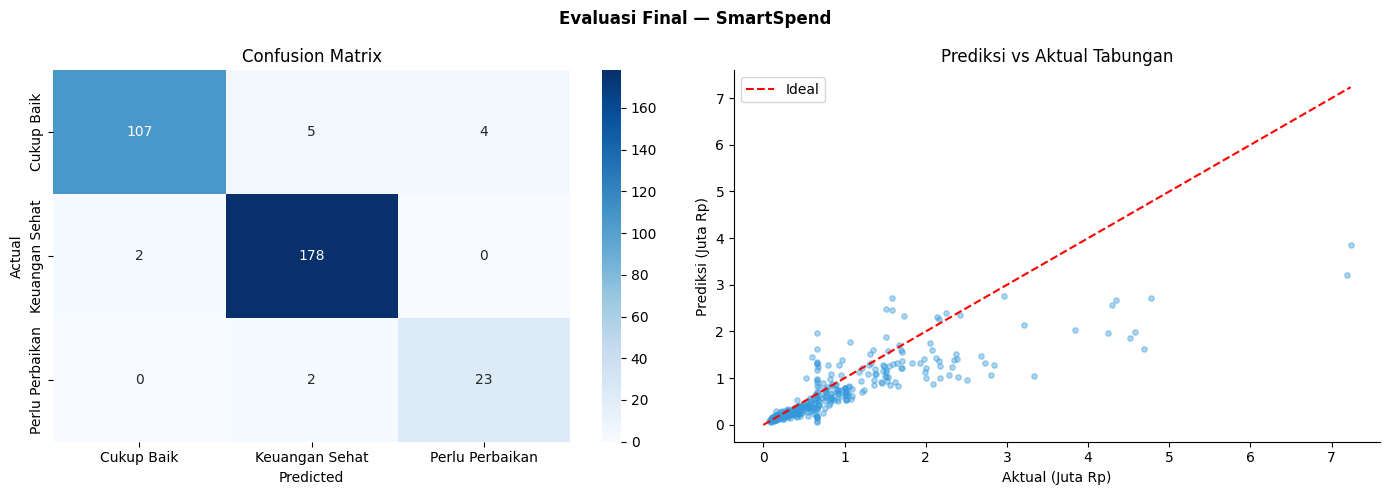

In [20]:
# ============================================================
# PERBAIKAN: Hitung MAE Rupiah dari prediksi aktual
# ============================================================

# Load model terbaik
best_model = keras.models.load_model(
    'smartspend_best_model.keras',
    custom_objects={'FinancialAttentionLayer': FinancialAttentionLayer}
)

# Prediksi pada test set
clf_pred_prob, reg_pred_log = best_model.predict(X_test, verbose=0)

# Konversi balik dari log-scale ke Rupiah asli
reg_pred_rupiah = np.expm1(reg_pred_log.flatten())
reg_true_rupiah = np.expm1(y_r_test_log)           # y_r_test_log = np.log1p(y_r_test)

# Hitung metrik regresi yang benar
mae  = np.mean(np.abs(reg_pred_rupiah - reg_true_rupiah))
rmse = np.sqrt(np.mean((reg_pred_rupiah - reg_true_rupiah) ** 2))
mape = np.mean(np.abs((reg_pred_rupiah - reg_true_rupiah) /
                       (reg_true_rupiah + 1))) * 100

# Hitung metrik klasifikasi
clf_pred_label = np.argmax(clf_pred_prob, axis=1)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('=' * 55)
print('📊 EVALUASI FINAL PADA TEST SET')
print('=' * 55)

# ── Klasifikasi ───────────────────────────────────────────────────
print('\n🎯 KLASIFIKASI KONDISI KEUANGAN')
print(classification_report(
    y_c_test,
    clf_pred_label,
    target_names=le_label.classes_
))

# ── Regresi ───────────────────────────────────────────────────────
print('💰 REGRESI NOMINAL TABUNGAN')
print(f'  MAE  : Rp {mae:>12,.0f}')
print(f'  RMSE : Rp {rmse:>12,.0f}')
print(f'  MAPE : {mape:.2f}%')

# Interpretasi MAE
if mae <= 200_000:
    grade_r = "🟢 SANGAT BAIK"
elif mae <= 500_000:
    grade_r = "🟡 BAIK"
elif mae <= 1_000_000:
    grade_r = "🟠 CUKUP"
else:
    grade_r = "🔴 PERLU DITINGKATKAN"

print(f'\n  Grade: {grade_r}')
print('=' * 55)

# ── Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Final — SmartSpend', fontweight='bold')

cm = confusion_matrix(y_c_test, clf_pred_label)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Scatter: prediksi vs aktual tabungan
axes[1].scatter(reg_true_rupiah / 1e6, reg_pred_rupiah / 1e6,
                alpha=0.4, color='#3498db', s=15)
max_val = max(reg_true_rupiah.max(), reg_pred_rupiah.max()) / 1e6
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal')
axes[1].set_title('Prediksi vs Aktual Tabungan')
axes[1].set_xlabel('Aktual (Juta Rp)')
axes[1].set_ylabel('Prediksi (Juta Rp)')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model

📊 RINGKASAN HASIL TRAINING
  Total epoch berjalan : 47
  Best epoch           : 32

  Best val_loss        : 0.1904
  Best val_acc         : 92.52%
  Best val_mae (log)   : 0.3860

  MAE dalam Rupiah     : Rp 0

  Klasifikasi grade    : 🟢 SANGAT BAIK (92.52%)
  Regresi grade        : 🟢 SANGAT BAIK (Rp 0)


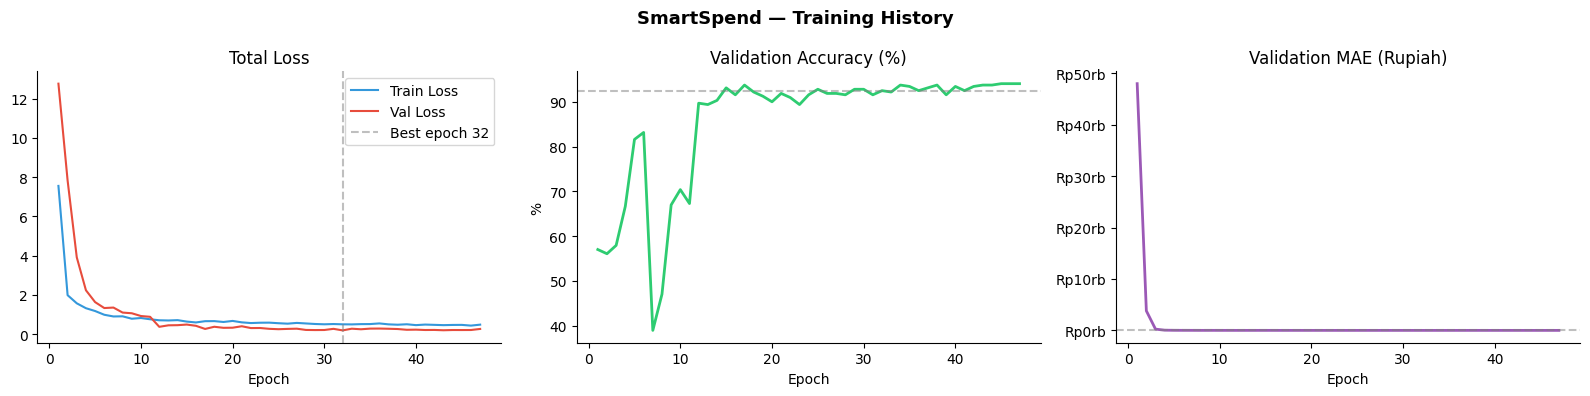

In [21]:
# ============================================================
# ANALISIS HASIL TRAINING
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import json

# Load history
with open('training_history.json') as f:
    log = json.load(f)

epochs     = [d['epoch']     for d in log]
train_loss = [d['train_loss'] for d in log]
val_loss   = [d['val_loss']   for d in log]
val_acc    = [d['val_acc']    for d in log]
val_mae    = [d['val_mae']    for d in log]

# ── Print ringkasan ───────────────────────────────────────────────
best     = min(log, key=lambda x: x['val_loss'])
last     = log[-1]

print('=' * 55)
print('📊 RINGKASAN HASIL TRAINING')
print('=' * 55)
print(f"  Total epoch berjalan : {len(log)}")
print(f"  Best epoch           : {best['epoch']}")
print()
print(f"  Best val_loss        : {best['val_loss']:.4f}")
print(f"  Best val_acc         : {best['val_acc']*100:.2f}%")
print(f"  Best val_mae (log)   : {best['val_mae']:.4f}")
print()

# Konversi MAE dari log-scale ke Rupiah
mae_rupiah = np.expm1(best['val_mae'])
print(f"  MAE dalam Rupiah     : Rp {mae_rupiah:,.0f}")
print()

# Interpretasi accuracy
acc = best['val_acc'] * 100
if acc >= 85:
    grade = "🟢 SANGAT BAIK"
elif acc >= 75:
    grade = "🟡 BAIK"
elif acc >= 65:
    grade = "🟠 CUKUP"
else:
    grade = "🔴 PERLU DITINGKATKAN"

print(f"  Klasifikasi grade    : {grade} ({acc:.2f}%)")

# Interpretasi MAE rupiah
if mae_rupiah <= 200_000:
    grade_r = "🟢 SANGAT BAIK"
elif mae_rupiah <= 500_000:
    grade_r = "🟡 BAIK"
elif mae_rupiah <= 1_000_000:
    grade_r = "🟠 CUKUP"
else:
    grade_r = "🔴 PERLU DITINGKATKAN"

print(f"  Regresi grade        : {grade_r} (Rp {mae_rupiah:,.0f})")
print('=' * 55)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SmartSpend — Training History', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs, train_loss, label='Train Loss', color='#3498db')
axes[0].plot(epochs, val_loss,   label='Val Loss',   color='#e74c3c')
axes[0].axvline(best['epoch'], color='gray', linestyle='--', alpha=0.5, label=f"Best epoch {best['epoch']}")
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Accuracy
axes[1].plot(epochs, [v*100 for v in val_acc], color='#2ecc71', linewidth=2)
axes[1].axhline(best['val_acc']*100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Validation Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# MAE → Rupiah
mae_rp = [np.expm1(v) for v in val_mae]
axes[2].plot(epochs, mae_rp, color='#9b59b6', linewidth=2)
axes[2].axhline(mae_rupiah, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Validation MAE (Rupiah)')
axes[2].set_xlabel('Epoch')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp{x/1e3:.0f}rb'))
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_result.png', dpi=150, bbox_inches='tight')
plt.show()

📊 EVALUASI KLASIFIKASI KONDISI KEUANGAN
                 precision    recall  f1-score   support

     Cukup Baik       0.98      0.92      0.95       116
 Keuangan Sehat       0.96      0.99      0.98       180
Perlu Perbaikan       0.85      0.92      0.88        25

       accuracy                           0.96       321
      macro avg       0.93      0.94      0.94       321
   weighted avg       0.96      0.96      0.96       321



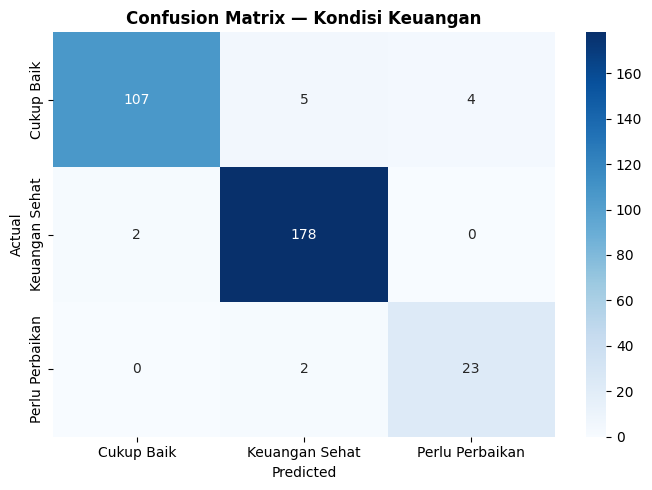


📊 EVALUASI REGRESI NOMINAL TABUNGAN
MAE  : Rp      351,598
RMSE : Rp      630,461
MAPE : 32.45%


In [22]:
# ── EVALUASI PADA TEST SET ────────────────────────────────────────
# Load model terbaik
best_model = keras.models.load_model(
    'smartspend_best_model.keras',
    custom_objects={'FinancialAttentionLayer': FinancialAttentionLayer}
)

# Prediksi
clf_pred_prob, reg_pred_log = best_model.predict(X_test, verbose=0)
clf_pred_label = np.argmax(clf_pred_prob, axis=1)
reg_pred_rupiah = np.expm1(reg_pred_log.flatten())  # Invers log1p

print('=' * 55)
print('📊 EVALUASI KLASIFIKASI KONDISI KEUANGAN')
print('=' * 55)
print(classification_report(
    y_c_test,
    clf_pred_label,
    target_names=le_label.classes_
))

# Confusion Matrix
cm = confusion_matrix(y_c_test, clf_pred_label)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_)
plt.title('Confusion Matrix — Kondisi Keuangan', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 55)
print('📊 EVALUASI REGRESI NOMINAL TABUNGAN')
print('=' * 55)
mae  = np.mean(np.abs(reg_pred_rupiah - y_r_test))
rmse = np.sqrt(np.mean((reg_pred_rupiah - y_r_test) ** 2))
mape = np.mean(np.abs((reg_pred_rupiah - y_r_test) / (y_r_test + 1))) * 100

print(f'MAE  : Rp {mae:>12,.0f}')
print(f'RMSE : Rp {rmse:>12,.0f}')
print(f'MAPE : {mape:.2f}%')

## 8. Simpan Model (Siap Produksi)
Menyimpan model dalam format `.keras` — format resmi TensorFlow yang mendukung custom layer.

In [23]:
# ── SIMPAN MODEL FINAL ────────────────────────────────────────────

# Format .keras (direkomendasikan untuk TF 2.x)
best_model.save('smartspend_model_final.keras')
print('✅ Model disimpan: smartspend_model_final.keras')

# Format SavedModel (untuk deployment ke TF Serving / backend)
best_model.export('smartspend_savedmodel')
print('✅ Model disimpan: smartspend_savedmodel/ (SavedModel format)')

# Simpan konfigurasi metadata
model_metadata = {
    'model_name'    : 'SmartSpend_DL_Model',
    'version'       : '1.0.0',
    'input_features': FEATURE_COLS,
    'input_dim'     : X_train.shape[1],
    'output': {
        'classification': {
            'name'   : 'classification_output',
            'classes': list(le_label.classes_)
        },
        'regression': {
            'name'     : 'regression_output',
            'unit'     : 'Rupiah (setelah invers log1p)',
            'log_scale': True
        }
    }
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False)

print('✅ Metadata disimpan: model_metadata.json')
print()
print('📁 File yang dihasilkan:')
for f in ['smartspend_best_model.keras', 'smartspend_model_final.keras',
          'smartspend_savedmodel', 'scaler.pkl', 'label_encoders.pkl',
          'label_encoder_target.pkl', 'provinsi_freq.pkl',
          'model_metadata.json', 'training_history.json']:
    exists = '✅' if os.path.exists(f) else '❌'
    print(f'  {exists} {f}')

✅ Model disimpan: smartspend_model_final.keras
Saved artifact at 'smartspend_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25), dtype=tf.float32, name='financial_features')
Output Type:
  List[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  133216352600720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352601296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352611472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352609360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352601104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352603984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352605328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133216352611088: TensorSpec(shape=(), dty

## 9. Kode Inference (Siap Produksi)
Fungsi inference ini akan dipanggil oleh backend Express.js untuk memberikan prediksi kepada pengguna SmartSpend.

In [24]:
# ============================================================
# INFERENCE PIPELINE — Siap Integrasi ke Backend
# ============================================================

class SmartSpendInference:
    """
    Kelas inference SmartSpend.
    Digunakan oleh backend Express.js via endpoint /api/ai/predict

    Usage:
    ------
    engine = SmartSpendInference()
    result = engine.predict(user_data)
    """

    def __init__(self,
                 model_path     ='smartspend_model_final.keras',
                 scaler_path    ='scaler.pkl',
                 le_path        ='label_encoders.pkl',
                 le_target_path ='label_encoder_target.pkl',
                 provinsi_path  ='provinsi_freq.pkl',
                 metadata_path  ='model_metadata.json'):

        print('⏳ Memuat model SmartSpend...')
        self.model = keras.models.load_model(
            model_path,
            custom_objects={'FinancialAttentionLayer': FinancialAttentionLayer}
        )
        self.scaler        = joblib.load(scaler_path)
        self.le_dict       = joblib.load(le_path)
        self.le_label      = joblib.load(le_target_path)
        self.provinsi_freq = joblib.load(provinsi_path)
        with open(metadata_path) as f:
            self.metadata = json.load(f)
        self.feature_cols  = self.metadata['input_features']
        print('✅ Model siap digunakan!')

    def _preprocess(self, user_data: dict) -> np.ndarray:
        """Preprocessing data user sebelum diinference."""
        df_user = pd.DataFrame([user_data])

        # Frequency encoding untuk provinsi
        df_user['provinsi_freq'] = df_user.get('provinsi', pd.Series(['DKI Jakarta'])).map(
            lambda x: self.provinsi_freq.get(x, 0.01)
        )

        # Label encode kolom kategorikal
        cat_cols = ['klasifikasi_wilayah', 'jenis_kelamin', 'pendidikan_terakhir',
                    'status_pekerjaan', 'status_pernikahan']
        for col in cat_cols:
            if col in df_user.columns:
                le = self.le_dict[col]
                val = df_user[col].iloc[0]
                # Handle unseen label
                if val in le.classes_:
                    df_user[col] = le.transform([val])
                else:
                    df_user[col] = 0  # Default ke kelas pertama
            else:
                df_user[col] = 0

        # Pastikan semua fitur tersedia
        for col in self.feature_cols:
            if col not in df_user.columns:
                df_user[col] = 0

        X = df_user[self.feature_cols].values.astype(np.float32)
        X = np.nan_to_num(X, nan=0.0)
        X_scaled = self.scaler.transform(X)
        return X_scaled

    def predict(self, user_data: dict) -> dict:
        """
        Inferensi utama: terima data user, kembalikan prediksi.

        Parameters
        ----------
        user_data : dict
            Data keuangan + demografi pengguna.

        Returns
        -------
        dict dengan kunci:
          - kondisi_keuangan  : str  ('Keuangan Sehat' / 'Cukup Baik' / 'Perlu Perbaikan')
          - confidence        : float (probabilitas prediksi 0-1)
          - probabilities     : dict  (probabilitas tiap kelas)
          - rekomendasi_tabungan : int (nominal tabungan ideal dalam Rupiah)
          - pesan             : str  (pesan motivasi)
        """
        X_input = self._preprocess(user_data)

        # Jalankan prediksi
        clf_probs, reg_log = self.model.predict(X_input, verbose=0)

        # Proses output klasifikasi
        class_idx  = int(np.argmax(clf_probs[0]))
        class_name = self.le_label.inverse_transform([class_idx])[0]
        confidence = float(clf_probs[0][class_idx])
        all_probs  = {
            label: round(float(prob), 4)
            for label, prob in zip(self.le_label.classes_, clf_probs[0])
        }

        # Proses output regresi
        tabungan_ideal = int(np.expm1(reg_log[0][0]))
        tabungan_ideal = max(tabungan_ideal, 0)  # Tidak boleh negatif

        # Generate pesan motivasi
        pesan_map = {
            'Keuangan Sehat'    : '🎉 Keuangan Anda sangat baik! Pertahankan dan tingkatkan investasi.',
            'Cukup Baik'        : '💪 Keuangan Anda cukup baik. Tingkatkan tabungan untuk keamanan lebih.',
            'Perlu Perbaikan'   : '⚠️ Keuangan perlu perhatian. Kurangi pengeluaran tidak perlu.'
        }

        return {
            'kondisi_keuangan'    : class_name,
            'confidence'          : round(confidence, 4),
            'probabilities'       : all_probs,
            'rekomendasi_tabungan': tabungan_ideal,
            'pesan'               : pesan_map.get(class_name, '')
        }


# Inisialisasi inference engine
engine = SmartSpendInference()

⏳ Memuat model SmartSpend...
✅ Model siap digunakan!


In [25]:
# ── DEMO INFERENCE ────────────────────────────────────────────────
test_users = [
    {
        'nama': 'Budi — Karyawan Swasta (kondisi kritis)',
        'data': {
            'provinsi': 'DKI Jakarta', 'klasifikasi_wilayah': 'Perkotaan',
            'jenis_kelamin': 'Laki-laki', 'usia': 28.0,
            'pendidikan_terakhir': 'S1', 'status_pekerjaan': 'Karyawan Swasta',
            'status_pernikahan': 'Belum Menikah', 'jumlah_tanggungan': 0.0,
            'pendapatan_bulanan': 4500000.0, 'total_pengeluaran': 4350000.0,
            'tabungan_bulanan': 150000.0, 'rasio_tabungan_persen': 3.3,
            'skor_literasi_keuangan': 35.0, 'cicilan_hutang': 800000.0,
            'pengeluaran_makanan_pokok': 400000.0, 'pengeluaran_lauk_pauk': 250000.0,
            'pengeluaran_sayur_buah': 100000.0, 'pengeluaran_jajan_makan_luar': 900000.0,
            'pengeluaran_rokok_tembakau': 300000.0, 'pengeluaran_perumahan_listrik': 750000.0,
            'pengeluaran_pakaian': 200000.0, 'pengeluaran_kesehatan': 100000.0,
            'pengeluaran_pendidikan': 0.0, 'pengeluaran_transportasi': 350000.0,
            'pengeluaran_komunikasi': 100000.0, 'pengeluaran_hiburan_rekreasi': 400000.0
        }
    },
    {
        'nama': 'Sari — PNS (kondisi sehat)',
        'data': {
            'provinsi': 'Jawa Barat', 'klasifikasi_wilayah': 'Perkotaan',
            'jenis_kelamin': 'Perempuan', 'usia': 35.0,
            'pendidikan_terakhir': 'S1', 'status_pekerjaan': 'PNS/ASN',
            'status_pernikahan': 'Menikah', 'jumlah_tanggungan': 2.0,
            'pendapatan_bulanan': 9000000.0, 'total_pengeluaran': 6000000.0,
            'tabungan_bulanan': 3000000.0, 'rasio_tabungan_persen': 33.3,
            'skor_literasi_keuangan': 75.0, 'cicilan_hutang': 1500000.0,
            'pengeluaran_makanan_pokok': 600000.0, 'pengeluaran_lauk_pauk': 400000.0,
            'pengeluaran_sayur_buah': 200000.0, 'pengeluaran_jajan_makan_luar': 500000.0,
            'pengeluaran_rokok_tembakau': 0.0, 'pengeluaran_perumahan_listrik': 1200000.0,
            'pengeluaran_pakaian': 300000.0, 'pengeluaran_kesehatan': 300000.0,
            'pengeluaran_pendidikan': 500000.0, 'pengeluaran_transportasi': 400000.0,
            'pengeluaran_komunikasi': 150000.0, 'pengeluaran_hiburan_rekreasi': 150000.0
        }
    }
]

for user in test_users:
    print('\n' + '─' * 55)
    print(f"👤 {user['nama']}")
    result = engine.predict(user['data'])
    print(f"   Kondisi Keuangan    : {result['kondisi_keuangan']}")
    print(f"   Confidence          : {result['confidence']*100:.1f}%")
    print(f"   Probabilities       : {result['probabilities']}")
    print(f"   Rekomendasi Tabungan: Rp {result['rekomendasi_tabungan']:,}")
    print(f"   Pesan               : {result['pesan']}")


───────────────────────────────────────────────────────
👤 Budi — Karyawan Swasta (kondisi kritis)
   Kondisi Keuangan    : Perlu Perbaikan
   Confidence          : 100.0%
   Probabilities       : {'Cukup Baik': 0.0, 'Keuangan Sehat': 0.0, 'Perlu Perbaikan': 1.0}
   Rekomendasi Tabungan: Rp 225,506
   Pesan               : ⚠️ Keuangan perlu perhatian. Kurangi pengeluaran tidak perlu.

───────────────────────────────────────────────────────
👤 Sari — PNS (kondisi sehat)
   Kondisi Keuangan    : Keuangan Sehat
   Confidence          : 99.7%
   Probabilities       : {'Cukup Baik': 0.0025, 'Keuangan Sehat': 0.9974, 'Perlu Perbaikan': 0.0}
   Rekomendasi Tabungan: Rp 1,685,801
   Pesan               : 🎉 Keuangan Anda sangat baik! Pertahankan dan tingkatkan investasi.


## 10. Ringkasan Checklist MVP

| No | Requirement | Status | Implementasi |
|---|---|---|---|
| 1 | TensorFlow Functional API / Model Subclassing | ✅ | `keras.Input` + `Model(inputs, outputs)` |
| 2 | Custom Layer | ✅ | `FinancialAttentionLayer` (attention mechanism) |
| 3 | Custom Callback | ✅ | `SmartSpendCallback` (monitor + auto-save + early stop) |
| 4 | Simpan model `.keras` | ✅ | `smartspend_model_final.keras` + `smartspend_savedmodel/` |
| 5 | Kode inference | ✅ | `SmartSpendInference` class siap integrasi ke Express.js |

---

**Cara integrasi ke backend Express.js:**
```javascript
// routes/ai.js
const { PythonShell } = require('python-shell');

router.post('/predict', async (req, res) => {
    const userData = req.body;
    const options = {
        mode: 'json',
        scriptPath: './ai',
        args: [JSON.stringify(userData)]
    };
    PythonShell.run('inference_api.py', options, (err, results) => {
        if (err) return res.status(500).json({ error: err.message });
        res.json(results[0]);
    });
});
```

# Tambahan

In [26]:
import os

files_needed = [
    'smartspend_best_model.keras',
    'smartspend_model_final.keras',
    'scaler.pkl',
    'label_encoders.pkl',
    'label_encoder_target.pkl',
    'provinsi_freq.pkl',
    'model_metadata.json',
    'training_history.json',
]

print('📁 PENGECEKAN FILE OUTPUT')
print('=' * 40)
all_ok = True
for f in files_needed:
    exists = os.path.exists(f)
    status = '✅' if exists else '❌ MISSING'
    print(f'  {status}  {f}')
    if not exists:
        all_ok = False

print('=' * 40)
print('✅ Semua file siap!' if all_ok else '❌ Ada file yang belum tersimpan, jalankan ulang cell Section 8')

📁 PENGECEKAN FILE OUTPUT
  ✅  smartspend_best_model.keras
  ✅  smartspend_model_final.keras
  ✅  scaler.pkl
  ✅  label_encoders.pkl
  ✅  label_encoder_target.pkl
  ✅  provinsi_freq.pkl
  ✅  model_metadata.json
  ✅  training_history.json
✅ Semua file siap!


In [28]:
# ============================================================
# SIMPAN inference_api.py ke disk
# ============================================================

inference_code = '''
import sys
import json
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras

class FinancialAttentionLayer(keras.layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W_attention = self.add_weight(
            name="W_attention",
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform", trainable=True)
        self.b_attention = self.add_weight(
            name="b_attention",
            shape=(self.units,),
            initializer="zeros", trainable=True)
        self.W_out = self.add_weight(
            name="W_out",
            shape=(self.units, input_shape[-1]),
            initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.W_attention) + self.b_attention)
        score = tf.matmul(score, self.W_out)
        attention_weights = tf.nn.softmax(score, axis=-1)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

model         = keras.models.load_model(
    "smartspend_model_final.keras",
    custom_objects={"FinancialAttentionLayer": FinancialAttentionLayer}
)
scaler        = joblib.load("scaler.pkl")
le_dict       = joblib.load("label_encoders.pkl")
le_label      = joblib.load("label_encoder_target.pkl")
provinsi_freq = joblib.load("provinsi_freq.pkl")

with open("model_metadata.json") as f:
    metadata = json.load(f)

FEATURE_COLS = metadata["input_features"]

def preprocess(user_data):
    import pandas as pd
    df = pd.DataFrame([user_data])

    df["provinsi_freq"] = df.get("provinsi", pd.Series(["DKI Jakarta"])).map(
        lambda x: provinsi_freq.get(x, 0.01))

    cat_cols = ["klasifikasi_wilayah", "jenis_kelamin", "pendidikan_terakhir",
                "status_pekerjaan", "status_pernikahan"]
    for col in cat_cols:
        le  = le_dict[col]
        val = df[col].iloc[0] if col in df.columns else le.classes_[0]
        df[col] = le.transform([val])[0] if val in le.classes_ else 0

    for col in FEATURE_COLS:
        if col not in df.columns:
            df[col] = 0

    X = df[FEATURE_COLS].values.astype(np.float32)
    X = np.nan_to_num(X, nan=0.0)
    return scaler.transform(X)

def predict(user_data):
    X = preprocess(user_data)
    clf_probs, reg_log = model.predict(X, verbose=0)

    class_idx  = int(np.argmax(clf_probs[0]))
    class_name = le_label.inverse_transform([class_idx])[0]
    confidence = float(clf_probs[0][class_idx])
    all_probs  = {
        label: round(float(prob), 4)
        for label, prob in zip(le_label.classes_, clf_probs[0])
    }
    tabungan_ideal = max(int(np.expm1(reg_log[0][0])), 0)

    pesan_map = {
        "Keuangan Sehat"  : "Keuangan Anda sangat baik! Pertahankan dan tingkatkan investasi.",
        "Cukup Baik"      : "Keuangan Anda cukup baik. Tingkatkan tabungan untuk keamanan lebih.",
        "Perlu Perbaikan" : "Keuangan perlu perhatian. Kurangi pengeluaran tidak perlu."
    }

    return {
        "kondisi_keuangan"    : class_name,
        "confidence"          : round(confidence, 4),
        "probabilities"       : all_probs,
        "rekomendasi_tabungan": tabungan_ideal,
        "pesan"               : pesan_map.get(class_name, "")
    }

if __name__ == "__main__":
    user_input = json.loads(sys.argv[1])
    result     = predict(user_input)
    print(json.dumps(result, ensure_ascii=False))
'''

with open('inference_api.py', 'w') as f:
    f.write(inference_code.strip())

print('✅ inference_api.py berhasil disimpan ke disk')

✅ inference_api.py berhasil disimpan ke disk


In [29]:
# ============================================================
# TEST INFERENCE — dijalankan langsung di notebook
# Tidak pakai sys.argv, langsung panggil fungsi predict()
# ============================================================

import importlib, inference_api
importlib.reload(inference_api)

test_data = {
    "provinsi"                     : "DKI Jakarta",
    "klasifikasi_wilayah"          : "Perkotaan",
    "jenis_kelamin"                : "Laki-laki",
    "usia"                         : 28.0,
    "pendidikan_terakhir"          : "S1",
    "status_pekerjaan"             : "Karyawan Swasta",
    "status_pernikahan"            : "Belum Menikah",
    "jumlah_tanggungan"            : 0.0,
    "pendapatan_bulanan"           : 5000000.0,
    "total_pengeluaran"            : 4200000.0,
    "tabungan_bulanan"             : 800000.0,
    "rasio_tabungan_persen"        : 16.0,
    "skor_literasi_keuangan"       : 55.0,
    "cicilan_hutang"               : 500000.0,
    "pengeluaran_makanan_pokok"    : 400000.0,
    "pengeluaran_lauk_pauk"        : 250000.0,
    "pengeluaran_sayur_buah"       : 100000.0,
    "pengeluaran_jajan_makan_luar" : 600000.0,
    "pengeluaran_rokok_tembakau"   : 0.0,
    "pengeluaran_perumahan_listrik": 800000.0,
    "pengeluaran_pakaian"          : 200000.0,
    "pengeluaran_kesehatan"        : 150000.0,
    "pengeluaran_pendidikan"       : 0.0,
    "pengeluaran_transportasi"     : 400000.0,
    "pengeluaran_komunikasi"       : 100000.0,
    "pengeluaran_hiburan_rekreasi" : 200000.0
}

result = inference_api.predict(test_data)

print('=' * 50)
print('🧪 HASIL TEST INFERENCE')
print('=' * 50)
print(f"  Kondisi Keuangan     : {result['kondisi_keuangan']}")
print(f"  Confidence           : {result['confidence']*100:.1f}%")
print(f"  Rekomendasi Tabungan : Rp {result['rekomendasi_tabungan']:,}")
print(f"  Pesan                : {result['pesan']}")
print()
print('  Probabilitas per kelas:')
for kelas, prob in result['probabilities'].items():
    bar = '█' * int(prob * 30)
    print(f"    {kelas:<20}: {bar} {prob*100:.1f}%")
print('=' * 50)

🧪 HASIL TEST INFERENCE
  Kondisi Keuangan     : Cukup Baik
  Confidence           : 99.4%
  Rekomendasi Tabungan : Rp 442,555
  Pesan                : Keuangan Anda cukup baik. Tingkatkan tabungan untuk keamanan lebih.

  Probabilitas per kelas:
    Cukup Baik          : █████████████████████████████ 99.4%
    Keuangan Sehat      :  0.5%
    Perlu Perbaikan     :  0.1%


# Download FIle

In [30]:
import shutil, os

# ── Buat struktur folder ──────────────────────────────────────────
os.makedirs('SmartSpend_AI/model',  exist_ok=True)
os.makedirs('SmartSpend_AI/preprocessing', exist_ok=True)
os.makedirs('SmartSpend_AI/config', exist_ok=True)
os.makedirs('SmartSpend_AI/api',    exist_ok=True)
os.makedirs('SmartSpend_AI/docs',   exist_ok=True)

# ── Copy file ke folder yang sesuai ──────────────────────────────
files = {
    # Model
    'smartspend_model_final.keras' : 'SmartSpend_AI/model/',
    'smartspend_savedmodel'        : 'SmartSpend_AI/model/smartspend_savedmodel',
    # Preprocessing
    'scaler.pkl'                   : 'SmartSpend_AI/preprocessing/',
    'label_encoders.pkl'           : 'SmartSpend_AI/preprocessing/',
    'label_encoder_target.pkl'     : 'SmartSpend_AI/preprocessing/',
    'provinsi_freq.pkl'            : 'SmartSpend_AI/preprocessing/',
    # Config
    'model_metadata.json'          : 'SmartSpend_AI/config/',
    # API
    'inference_api.py'             : 'SmartSpend_AI/api/',
    # Docs
    'confusion_matrix.png'         : 'SmartSpend_AI/docs/',
    'final_evaluation.png'         : 'SmartSpend_AI/docs/',
    'training_result.png'          : 'SmartSpend_AI/docs/',
    'training_history.json'        : 'SmartSpend_AI/docs/',
}

for src, dst in files.items():
    if os.path.exists(src):
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
        print(f'✅ {src}')
    else:
        print(f'❌ MISSING: {src}')

# ── Zip semua jadi satu file ──────────────────────────────────────
shutil.make_archive('SmartSpend_AI_Package', 'zip', '.', 'SmartSpend_AI')
print('\n📦 SmartSpend_AI_Package.zip siap didownload / upload ke GitHub!')

✅ smartspend_model_final.keras
✅ smartspend_savedmodel
✅ scaler.pkl
✅ label_encoders.pkl
✅ label_encoder_target.pkl
✅ provinsi_freq.pkl
✅ model_metadata.json
✅ inference_api.py
✅ confusion_matrix.png
✅ final_evaluation.png
✅ training_result.png
✅ training_history.json

📦 SmartSpend_AI_Package.zip siap didownload / upload ke GitHub!


In [31]:
from google.colab import files
files.download('SmartSpend_AI_Package.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>